# From Sputnik's beeps to Sentinel: Tracking satellites via Doppler
*Code Beyond the Earth · World Space Week 2026 ("Rocket Revolution")*

Sputnik 1 was launched on October 4, 1957. The satellite broadcast short beeps at 20.005 and 40.002 MHz. A few days later, William Guier and George Weiffenbach at Johns Hopkins APL recorded this signal. The pitch of the sound rose as the satellite approached and fell as it receded. From this Doppler curve, they deduced the **satellite's orbit**. Subsequently, Frank McClure proposed the inverse: if the orbit is known, the **receiver's location** can be determined from the same curve. This idea paved the way for the Transit satellite navigation system and, eventually, GPS.

In this notebook, we will apply the same physics to modern Earth observation satellites:

1. The mathematics of Doppler shift
2. A satellite's radial velocity relative to us ("range-rate")
3. Locating Sentinel satellites passing over Kartal this week
4. Doppler curves for the same pass at 20 MHz (Sputnik) and ~8 GHz (Sentinel X-band)
5. **Inverse problem:** reconstructing the pass geometry from noisy Doppler data (the essence of what was done in 1957)
6. Bonus: an approximate Sputnik orbit and sonification of the beep as a `.wav` file

In [2]:
!pip install skyfield sgp4 scipy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.1/371.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.4 MB/s eta 0:00:00


In [3]:
# pip install skyfield sgp4 scipy matplotlib pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from skyfield.api import load, wgs84, EarthSatellite
from skyfield.framelib import itrs
from sgp4.api import Satrec, WGS72

C_LIGHT = 299_792_458.0          # m/s
ts = load.timescale()

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2,
})

## 1. Mathematics I: Doppler shift

Let a transmitter with frequency $f_0$ be moving away from us at a speed $v_r$ ($v_r>0$ for receding, $v_r<0$ for approaching).

**Classical derivation.** The transmitter emits wave crests at intervals of $T_0 = 1/f_0$. Since the transmitter moves away by a distance of $v_r T_0$ between two crests, it takes an additional $v_r T_0 / c$ for the second crest to reach us. Therefore, the observed period is:

$$T = T_0\left(1 + \frac{v_r}{c}\right) \quad\Rightarrow\quad f = \frac{f_0}{1 + v_r/c} \approx f_0\left(1 - \frac{v_r}{c}\right)$$

The final step is a first-order Taylor expansion. It works very well because $v_r/c$ is small. In LEO, $v \approx 7.5$ km/s and $v/c \approx 2.5\times 10^{-5}$.

$$\boxed{\;\Delta f = f - f_0 \approx -\,f_0\,\frac{v_r}{c}\;}$$

**Why it matters:** The shift is **proportional** to $f_0$. The same pass yields a shift of ~±500 Hz at 20 MHz, and ~±200 kHz at 8 GHz. The shape of the curve is identical; the scale differs by a factor of 400.

*Relativity note:* The exact expression is $f = f_0\sqrt{\frac{1-\beta}{1+\beta}}$ (radial motion, $\beta=v_r/c$). Second-order terms are at the ~$10^{-10}$ level. It is important in precision systems like GPS, but for us, it is negligible.

## 2. Mathematics II: Radial velocity (range-rate)

Let $\mathbf{r}_s(t)$ be the satellite's position and $\mathbf{r}_o(t)$ be the observer's position. The line-of-sight vector and the range are:

$$\boldsymbol{\rho} = \mathbf{r}_s - \mathbf{r}_o, \qquad \rho = \|\boldsymbol{\rho}\|$$

Radial velocity is the time derivative of the range. Differentiating the expression $\rho^2 = \boldsymbol\rho\cdot\boldsymbol\rho$ yields $2\rho\dot\rho = 2\boldsymbol\rho\cdot\dot{\boldsymbol\rho}$. From this:

$$\boxed{\;v_r = \dot\rho = \frac{\boldsymbol\rho\cdot\dot{\boldsymbol\rho}}{\rho} = \hat{\boldsymbol\rho}\cdot(\mathbf{v}_s - \mathbf{v}_o)\;}$$

In other words, it is the **projection of the relative velocity onto the line of sight**. When the satellite passes directly overhead, the relative velocity is perpendicular to the line of sight; thus, $v_r = 0$ and $\Delta f = 0$.

**Reference frame pitfall:** $\mathbf{r}_s$ and $\mathbf{r}_o$ must be in the same frame. Since the observer rotates with the Earth, the easiest approach is to define both positions in the **ITRS** frame, which is fixed to the Earth. In this frame, the observer's velocity is zero. Below, we calculate the formula manually using this method and compare the result with the value provided by Skyfield.

## 3. Satellites and the observer

We obtain TLE (Two-Line Element) data from CelesTrak's **resource** group—specifically, Earth observation satellites. The SGP4 model propagates the orbit based on these elements.

If there is no internet connection or CelesTrak is inaccessible, we generate a **synthetic** satellite similar to Sentinel-2: sun-synchronous, at an altitude of ~786 km and an inclination of 98.6°. The physics remains the same; only the pass times are not real.

In [5]:
KARTAL = wgs84.latlon(40.89, 29.19, elevation_m=30)
TLE_URL = "https://celestrak.org/NORAD/elements/gp.php?GROUP=resource&FORMAT=tle"

def synthetic_sentinel(ts, alt_km=786.0, inc_deg=98.57, raan_deg=0.0):
    # Sentinel-2 benzeri dairesel yörünge, epoch = şimdi
    mu, Re = 398600.4418, 6378.137
    a = Re + alt_km
    n_rad_min = np.sqrt(mu / a**3) * 60.0
    now = ts.now()
    epoch = now.ut1 - 2433281.5          # 1949-12-31 00:00 UT'den beri gün
    s = Satrec()
    s.sgp4init(WGS72, 'i', 99999, epoch, 0.0, 0.0, 0.0, 1e-4,
               np.radians(90), np.radians(inc_deg), 0.0, n_rad_min, np.radians(raan_deg))
    return EarthSatellite.from_satrec(s, ts)

try:
    sats = load.tle_file(TLE_URL, filename="resource.tle", reload=True)
    SOURCE = "CelesTrak (canlı TLE)"
except Exception as e:
    print("CelesTrak cannot reached, sentetic satellite will be used:", type(e).__name__)
    sats = []
    SOURCE = "sentetic"

by_name = {s.name: s for s in sats}
sentinels = {n: s for n, s in by_name.items() if n.startswith("SENTINEL-2") or n.startswith("SENTINEL-3")}
if not sentinels:
    sentinels = {"SENTINEL-2 (sentetik)": synthetic_sentinel(ts)}

print("Kaynak:", SOURCE)
for n, s in sentinels.items():
    print(f"  {n:24s} epoch {s.epoch.utc_strftime('%Y-%m-%d %H:%M')} UTC")

[#################################] 100% resource.tle


Kaynak: CelesTrak (canlı TLE)
  SENTINEL-2A              epoch 2026-10-04 22:26 UTC
  SENTINEL-3A              epoch 2026-10-04 21:36 UTC
  SENTINEL-2B              epoch 2026-10-04 22:16 UTC
  SENTINEL-3B              epoch 2026-10-04 22:38 UTC
  SENTINEL-2C              epoch 2026-10-04 19:45 UTC


## 4. Passes over Kartal this week

`find_events` identifies the moments when the satellite rises above the horizon (0), reaches its peak elevation (1), and sets (2). The Doppler curve is clearest during passes with high elevation angles; therefore, we retain only those passes with an elevation of at least 30°.

In [6]:
t0 = ts.now()
t1 = ts.tt_jd(t0.tt + 7)
MIN_PEAK = 30.0

rows = []
for name, sat in sentinels.items():
    times, events = sat.find_events(KARTAL, t0, t1, altitude_degrees=0.0)
    # olayları (rise, culm, set) üçlülerine grupla
    for i in range(len(events) - 2):
        if tuple(events[i:i+3]) == (0, 1, 2):
            tr, tc, tset = times[i:i+3]
            alt, az, _ = (sat - KARTAL).at(tc).altaz()
            if alt.degrees >= MIN_PEAK:
                rows.append(dict(sat=name, rise=tr, culm=tc, set=tset,
                                 peak_alt=round(alt.degrees, 1),
                                 dur_min=round((tset.tt - tr.tt) * 1440, 1)))

passes = pd.DataFrame(rows).sort_values("peak_alt", ascending=False).reset_index(drop=True)
show = passes.assign(culm_tr=passes.culm.apply(lambda t: t.utc_datetime().astimezone().strftime("%a %d %b %H:%M")))
show[["sat", "culm_tr", "peak_alt", "dur_min"]]

,sat,culm_tr,peak_alt,dur_min
0,SENTINEL-3A,Fri 09 Oct 19:36,85.9,15.2
1,SENTINEL-2A,Fri 09 Oct 20:06,84.8,15.0
2,SENTINEL-2C,Wed 07 Oct 20:06,84.8,15.0
3,SENTINEL-3B,Wed 07 Oct 08:30,83.4,15.2
4,SENTINEL-2A,Mon 12 Oct 08:59,83.2,15.1
...,...,...,...,...
66,SENTINEL-2A,Wed 07 Oct 09:48,34.8,14.3
67,SENTINEL-2B,Sat 10 Oct 09:48,34.8,14.3
68,SENTINEL-2B,Wed 07 Oct 19:16,34.1,14.3
69,SENTINEL-3A,Sun 11 Oct 18:44,32.8,14.3


### Sky map
In the polar plot, the center is the zenith (90°) and the edge is the horizon (0°). The path of the highest transit we selected:

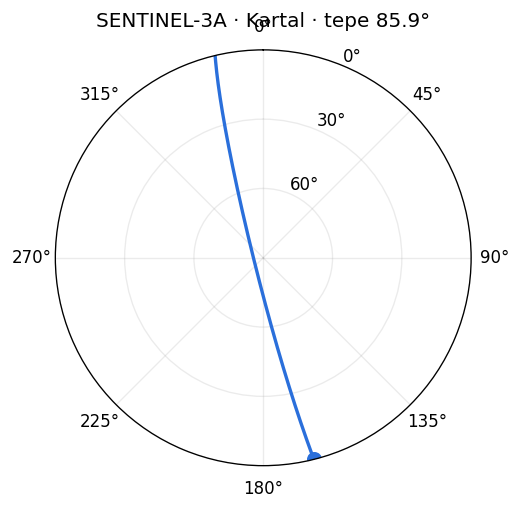

In [7]:
P = passes.iloc[0]
sat = sentinels[P.sat]
t = ts.linspace(P.rise, P.set, 600)
topo = (sat - KARTAL).at(t)
alt, az, dist = topo.altaz()

fig = plt.figure(figsize=(4.5, 4.5))
ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.plot(az.radians, 90 - alt.degrees, color="#2a6fdb")
ax.plot(az.radians[0], 90 - alt.degrees[0], "o", ms=8, color="#2a6fdb")
ax.set_rlim(0, 90); ax.set_yticks([30, 60, 90]); ax.set_yticklabels(["60°", "30°", "0°"])
ax.set_title(f"{P.sat} · Kartal · tepe {P.peak_alt}°", pad=14)
plt.show()

## 5. Range-rate: manually and with Skyfield

We apply the formula from Section 2 within the ITRS frame: $v_r = \hat{\boldsymbol\rho}\cdot\dot{\boldsymbol\rho}$. We compare the result with the output of Skyfield's `frame_latlon_and_rates`. The two should match.

In [9]:
# Elle: ITRS'de bağıl konum ve hız
rho_vec, rho_dot = topo.frame_xyz_and_velocity(itrs)
rho = rho_vec.m                                   # (3, N) metre
rhod = rho_dot.m_per_s                            # (3, N) m/s
vr_manual = np.sum(rho * rhod, axis=0) / np.linalg.norm(rho, axis=0)

# Skyfield'ın hazır değeri
*_, range_rate = topo.frame_latlon_and_rates(KARTAL)
vr_sky = range_rate.m_per_s

print(f"maks. diffrence: {np.max(np.abs(vr_manual - vr_sky)):.2e} m/s")
print(f"v_r interval: {vr_manual.min()/1e3:.2f} … {vr_manual.max()/1e3:.2f} km/s")

maks. diffrence: 3.64e-12 m/s
v_r interval: -6.70 … 6.68 km/s


## 6. Same pass, two different frequencies

- **20.005 MHz:** Sputnik's frequency
- **8.1 GHz:** An approximate X-band data downlink frequency (Sentinels downlink data via this band; the exact channel frequency is not important here)

Since two scales do not fit on a single axis, we use two panels side by side.

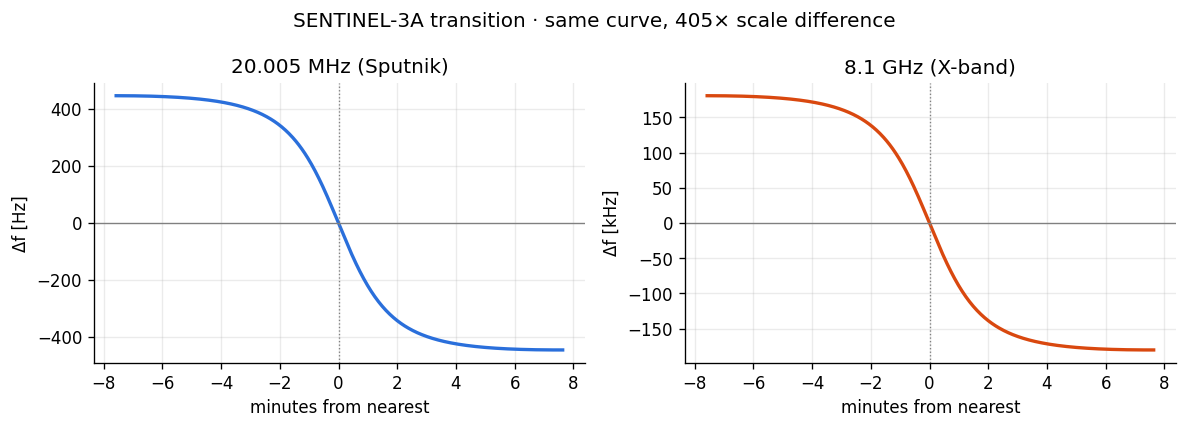

In [11]:
F_SPUTNIK = 20.005e6
F_XBAND = 8.1e9
minutes = (t.tt - P.culm.tt) * 1440

df_sput = -F_SPUTNIK * vr_sky / C_LIGHT
df_x = -F_XBAND * vr_sky / C_LIGHT

fig, axs = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
axs[0].plot(minutes, df_sput, color="#2a6fdb")
axs[0].set_title("20.005 MHz (Sputnik)"); axs[0].set_ylabel("Δf [Hz]")
axs[1].plot(minutes, df_x / 1e3, color="#d9480f")
axs[1].set_title("8.1 GHz (X-band)"); axs[1].set_ylabel("Δf [kHz]")
for a in axs:
    a.axhline(0, color="0.5", lw=0.8); a.axvline(0, color="0.5", lw=0.8, ls=":")
    a.set_xlabel("minutes from nearest")
fig.suptitle(f"{P.sat} transition · same curve, {F_XBAND/F_SPUTNIK:.0f}× scale difference")
plt.tight_layout(); plt.show()

## 7. Mathematics III: The inverse problem (the essence of 1957)

Guier and Weiffenbach had only **frequency versus time** data. How can geometry be derived from this curve?

**Simple model: straight-line pass.** Let us consider the satellite as a point moving in a straight line at constant speed during a brief pass. Let $d$ be the closest distance, $v$ the speed, and $t_0$ the time of closest approach. By the Pythagorean theorem:

$$\rho(t) = \sqrt{d^2 + v^2 (t-t_0)^2}$$

Taking the derivative:

$$v_r(t) = \dot\rho = \frac{v^2 (t-t_0)}{\sqrt{d^2 + v^2 (t-t_0)^2}}$$

The Doppler model is then (where $b$ is the unknown frequency offset between receiver and transmitter):

$$\Delta f(t) = -\frac{f_0}{c}\,\frac{v^2 (t-t_0)}{\sqrt{d^2 + v^2 (t-t_0)^2}} + b$$

**How ​​the curve "reveals" the geometry:**

| Curve feature | Mathematics | What it yields |
|---|---|---|
| Zero crossing | $\Delta f = b$, $t=t_0$ | time of closest approach |
| Asymptote at the ends | $\Delta f \to \mp f_0 v/c$ | speed $v$ |
| Slope at zero | $\left.\frac{d\Delta f}{dt}\right|_{t_0} = -\frac{f_0 v^2}{c\,d}$ | **closest distance $d$** |

The last line is the key. A close pass corresponds to a steep curve, while a distant pass corresponds to a shallow curve. Measuring the slope effectively measures the distance.

Below, we add noise to the true (SGP4) curve and fit the model using `curve_fit` (nonlinear least squares). We then compare the resulting $d$ and $v$ values ​​with the true values.

In [12]:
rng = np.random.default_rng(1957)
f0 = F_SPUTNIK
tsec = (t.tt - P.culm.tt) * 86400.0

# "ölçüm": gerçek Doppler + bilinmeyen sapma + gürültü
true_bias = 37.0                               # Hz
noise_hz = 5.0
meas = -f0 * vr_sky / C_LIGHT + true_bias + rng.normal(0, noise_hz, tsec.size)

def model(t, t0, d, v, b):
    x = t - t0
    return -(f0 / C_LIGHT) * v**2 * x / np.sqrt(d**2 + v**2 * x**2) + b

p0 = [0.0, 1.0e6, 7.0e3, 0.0]                  # kaba başlangıç: 1000 km, 7 km/s
popt, pcov = curve_fit(model, tsec, meas, p0=p0)
perr = np.sqrt(np.diag(pcov))
t0_f, d_f, v_f, b_f = popt

d_true = dist.m.min()
print(f"closest distance d : fit {d_f/1e3:7.1f} km   true {d_true/1e3:7.1f} km")
print(f"velocity v         : fit {v_f/1e3:7.2f} km/s (orbital velocity ~7.45 km/s)")
print(f"time of closest approach t0 : fit {t0_f:+6.1f} s (true 0)")
print(f"frequency bias b   : fit {b_f:6.1f} Hz (actual {true_bias})")

closest distance d : fit   766.0 km   true   809.7 km
velocity v         : fit    6.96 km/s (orbital velocity ~7.45 km/s)
time of closest approach t0 : fit   -0.5 s (true 0)
frequency bias b   : fit   37.7 Hz (actual 37.0)


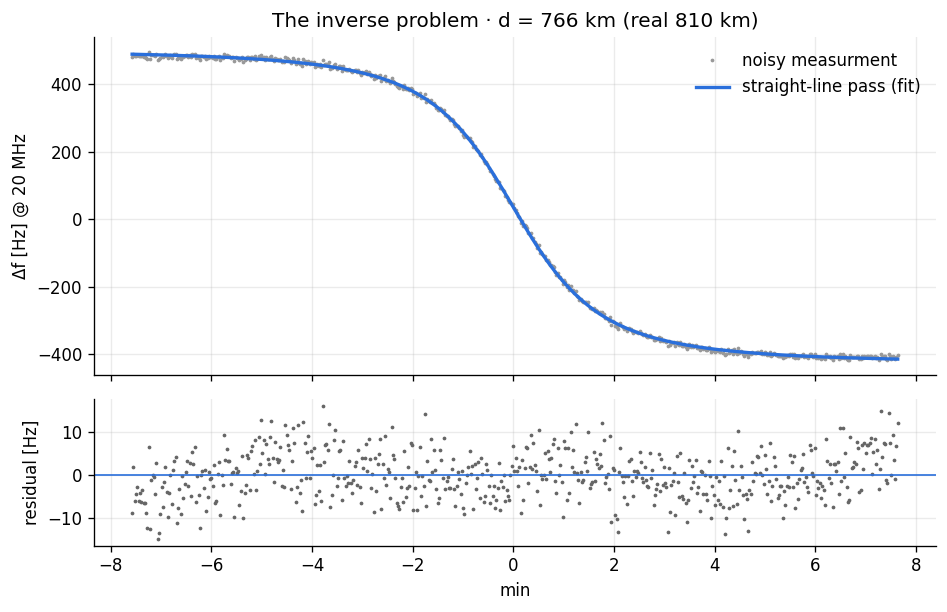

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True, gridspec_kw=dict(height_ratios=[3, 1.3]))
axs[0].plot(tsec/60, meas, ".", ms=2.5, color="0.6", label="noisy measurment")
axs[0].plot(tsec/60, model(tsec, *popt), color="#2a6fdb", label="straight-line pass (fit)")
axs[0].set_ylabel("Δf [Hz] @ 20 MHz"); axs[0].legend(frameon=False)
axs[0].set_title(f"The inverse problem · d = {d_f/1e3:.0f} km (real {d_true/1e3:.0f} km)")
resid = meas - model(tsec, *popt)
axs[1].plot(tsec/60, resid, ".", ms=2.5, color="0.4")
axs[1].axhline(0, color="#2a6fdb", lw=1)
axs[1].set_ylabel("residual [Hz]"); axs[1].set_xlabel("min")
plt.tight_layout(); plt.show()

**Interpreting the residuals:** If you see a systematic pattern alongside the noise, it indicates a shortcoming in the model—specifically regarding orbital curvature, Earth's rotation, and the changing viewing angle at distant points. The straight-line model performs very well near the peak but is less accurate closer to the horizon.

The actual solution adopted in 1957 was to fit the **full orbital model** (using 6 Keplerian elements) to data from multiple passes, rather than using a straight-line approximation. The logic remains the same, but the model is more comprehensive. To test this, try limiting `curve_fit` to data near the peak (e.g., `np.abs(tsec) < 120`) and observe how the estimate for $d$ changes.

### McClure's inversion
The model is symmetric: the pair $(t_0, d)$ defines the geometry between the satellite and the observer. If the orbit is known, $t_0$ indicates your position relative to a specific point along the satellite's ground track, while $d$ specifies your distance from that track. This is the operating principle of the Transit navigation system. The only ambiguity is **which side** of the track you are on—a problem resolved by a second pass.

## 8. Bonus: Sputnik 1 and the beep

Approximate orbit of Sputnik: perigee ~215 km, apogee ~939 km, inclination 65.1°, period ~96 min. The RAAN and argument of perigee values ​​used here are **assumed** for demonstration purposes. Therefore, the resulting pass is not a historical one, but a physically consistent example.

Shortwave listeners monitored the signal by converting it into an audible tone of ~1 kHz using a BFO. The Doppler shift directly altered the pitch of this tone. We generate the audible tone as $800\text{ Hz} + \Delta f(t)$. The beep interval is ~0.3 s; we compress the ~10-minute pass into ~40 seconds.

In [15]:
from scipy.io import wavfile

def sputnik_sat(ts):
    mu, Re = 398600.4418, 6378.137
    rp, ra = Re + 215.0, Re + 939.0
    a, e = (rp + ra) / 2, (ra - rp) / (ra + rp)
    n = np.sqrt(mu / a**3) * 60.0
    epoch = ts.utc(1957, 10, 4, 19, 28, 34).ut1 - 2433281.5    # fırlatma anı (UTC)
    s = Satrec()
    s.sgp4init(WGS72, 'i', 2, epoch, 0.0, 0.0, 0.0, e,
               np.radians(60.0), np.radians(65.1), 0.0, n, np.radians(40.0))
    return EarthSatellite.from_satrec(s, ts)

sput = sputnik_sat(ts)
tA, tB = ts.utc(1957, 10, 5), ts.utc(1957, 10, 7)
times, ev = sput.find_events(KARTAL, tA, tB, altitude_degrees=0.0)
best = None
for i in range(len(ev) - 2):
    if tuple(ev[i:i+3]) == (0, 1, 2):
        alt = (sput - KARTAL).at(times[i+1]).altaz()[0].degrees
        if best is None or alt > best[0]:
            best = (alt, times[i], times[i+2])
print(f"Sample Sputnik pass: top {best[0]:.0f}°, {best[1].utc_strftime('%Y-%m-%d %H:%M')} UTC")

tp = ts.linspace(best[1], best[2], 2000)
*_, rr = (sput - KARTAL).at(tp).frame_latlon_and_rates(KARTAL)
df_sp = -F_SPUTNIK * rr.m_per_s / C_LIGHT
print(f"Doppler interval: {df_sp.min():+.0f} … {df_sp.max():+.0f} Hz")

Sample Sputnik pass: top 74°, 1957-10-05 10:08 UTC
Doppler interval: -457 … +472 Hz


sputnik_doppler.wav yazıldı


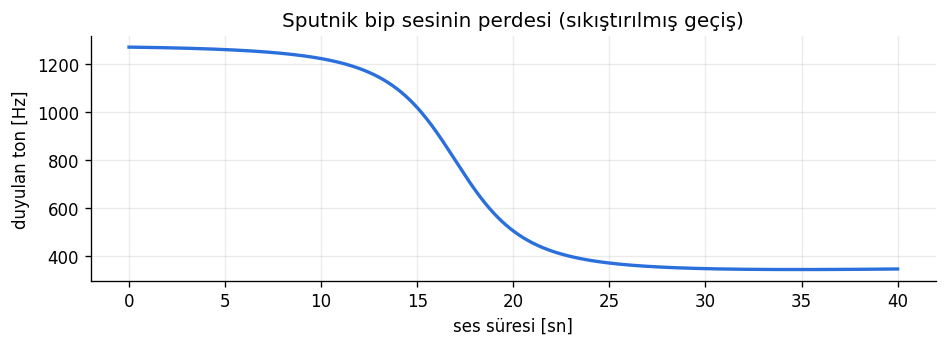

In [16]:
SR, AUDIO_SEC, BASE = 22050, 40.0, 800.0
n = int(SR * AUDIO_SEC)
ta = np.linspace(0, AUDIO_SEC, n, endpoint=False)
tone = BASE + np.interp(ta, np.linspace(0, AUDIO_SEC, df_sp.size), df_sp)
phase = 2 * np.pi * np.cumsum(tone) / SR                        # değişken frekans → fazı entegre et
gate = (np.floor(ta / 0.3) % 2 == 0).astype(float)              # 0.3 sn bip, 0.3 sn sessizlik
audio = 0.4 * np.sin(phase) * gate
wavfile.write("sputnik_doppler.wav", SR, (audio * 32767).astype(np.int16))
print("sputnik_doppler.wav yazıldı")

plt.figure(figsize=(8, 3))
plt.plot(np.linspace(0, AUDIO_SEC, df_sp.size), BASE + df_sp, color="#2a6fdb")
plt.xlabel("ses süresi [sn]"); plt.ylabel("duyulan ton [Hz]")
plt.title("Sputnik bip sesinin perdesi (sıkıştırılmış geçiş)")
plt.tight_layout(); plt.show()

**Why phase integration?** Writing a sine wave with a time-varying frequency as `sin(2π f(t) t)` is incorrect because the instantaneous frequency is defined as $\frac{1}{2\pi}\frac{d\phi}{dt}$. The correct approach is $\phi(t) = 2\pi\int f\,dt$, or in discrete form, `cumsum(f)/SR`.

## References
- W. H. Guier & G. C. Weiffenbach, "Genesis of Satellite Navigation", *Johns Hopkins APL Technical Digest* 19(1), 1998. Provides a first-hand account of the story with intuitive mathematics.
- H. D. Curtis, *Orbital Mechanics for Engineering Students*. Chapter 2 (two-body problem), Chapter 4 (orbital elements), Chapter 5 (orbit determination from observations).
- D. A. Vallado, *Fundamentals of Astrodynamics and Applications*. Comprehensive reference for SGP4, reference frames, and orbit determination.
- Skyfield documentation, "Earth Satellites" page: `find_events`, `frame_latlon_and_rates`.
- T. S. Kelso, CelesTrak: Notes on the TLE format and SGP4.